# 🌲 06 — Random Forest Model Training & Evaluation

This notebook trains **Random Forest** models for regression and classification on the model-ready air quality dataset. It mirrors the SVM notebook structure with clean sections, metrics, plots, and saved artifacts.

### 🧒 Easy guide (Inputs & Outputs)
- **Input:** data files in `data/processed/` (train/val/test or full dataset).
- Each row is one forest plot. **Features** are clues; the **target** is the answer.
- **Output:** trained models saved in `outputs/models/`, scores saved in `outputs/reports/`, and plots shown on screen.
- **Random Forest** means many small trees vote on the answer.

## 0. Setup & Imports

In [ ]:
# ── Google Colab & Local auto-setup ─────────────────────────────────────────-
import os, sys

# 1. FIX WORKING DIRECTORY (Crucial for VS Code)
# If running from notebooks/ subdir, move up to repo root
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

# Ensure repo root is in sys.path so 'src' is importable
repo_root = os.getcwd()
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

# 2. GOOGLE COLAB WORKFLOW
if 'google.colab' in sys.modules:
    REPO_DIR = 'Air_Quality_Predictor'
    # Clone the repo if not already done
    if not os.path.exists(REPO_DIR):
        !git clone https://github.com/shashi2024/Air_Quality_Predictor.git
    os.chdir(REPO_DIR)

    # Install dependencies
    !pip install -r requirements.txt -q

    # Run the data pipeline notebooks (01-05) if processed data doesn't exist
    import subprocess
    data_ready = (
        os.path.exists(os.path.join('data', 'processed', 'train.parquet')) or
        os.path.exists(os.path.join('data', 'processed', 'train.csv'))
    )
    if not data_ready:
        print('⏳ Running data pipeline notebooks 01-05... (this may take 10-20 minutes)')
        for nb_name in [
            '01_data_ingestion', '02_eda_exploration', '03_preprocessing',
            '04_feature_extraction', '05_model_ready_dataset'
        ]:
            nb_path = os.path.join('notebooks', f'{nb_name}.ipynb')
            print(f'   ▶ Running {nb_name}.ipynb ...')
            result = subprocess.run(
                ['jupyter', 'nbconvert', '--to', 'notebook', '--execute',
                 '--ExecutePreprocessor.timeout=1800',
                 '--ExecutePreprocessor.kernel_name=python3',
                 nb_path, '--output', nb_path],
                capture_output=True, text=True
            )
            if result.returncode != 0:
                print(f'   ⚠️  {nb_name} had warnings/errors\n{result.stderr[-300:]}')
            else:
                print(f'   ✅ {nb_name} done')
        print('✅ Data pipeline complete!')
    else:
        print('✅ Processed data already exists, skipping pipeline notebooks.')

print(f'Working directory: {os.getcwd()}')
print(f'src/ exists: {os.path.exists("src")}')
print(f'data/processed/ exists: {os.path.exists(os.path.join("data", "processed"))}')

In [ ]:
import json
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)

RANDOM_STATE = 42
N_ESTIMATORS = 300

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='deep', font_scale=1.05)

print('✅ All imports successful!')
print(f'   Random state: {RANDOM_STATE}')

## 1. Load the Model-Ready Dataset

We load the cleaned dataset made by notebooks 01–05. If those files are missing, run the earlier notebooks first.

In [ ]:
# ── Configuration ───────────────────────────────────────────────────
DATA_DIR     = os.path.join('data', 'processed')
OUTPUT_DIR   = os.path.join('outputs')
FIGURES_DIR  = os.path.join(OUTPUT_DIR, 'figures')
REPORTS_DIR  = os.path.join(OUTPUT_DIR, 'reports')
MODELS_DIR   = os.path.join(OUTPUT_DIR, 'models')

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

# ── Load data card ──────────────────────────────────────────────────
card_path = os.path.join(DATA_DIR, 'data_card.json')
with open(card_path) as f:
    data_card = json.load(f)

FEATURE_COLS = data_card['features']
TARGETS      = data_card['targets']
WEIGHT_COL   = data_card.get('sample_weight_col', 'sample_weight')

CLASSIFICATION_KEYS = ['binary_classification', 'multiclass_3']

print(f'📊 Dataset: {data_card["dataset_name"]}')
print(f'   Samples : {data_card["n_total"]:,}')
print(f'   Features: {data_card["n_features"]}')
print(f'   Split   : {data_card["split_strategy"]}')
print(f'\n📌 Target columns:')
for k, v in TARGETS.items():
    print(f'   {k:25s} → {v}')
print(f'\n📌 Features ({len(FEATURE_COLS)}):')
for f in FEATURE_COLS:
    print(f'   • {f}')

This step reads the train/val/test files so we can teach the model and then test it.

In [ ]:
# ── Load dataset splits ─────────────────────────────────────────────
# Try parquet first, then CSV

def read_table(path):
    return pd.read_parquet(path) if path.endswith('.parquet') else pd.read_csv(path)

loaded = False

df_train = df_val = df_test = None

for ext in ['.parquet', '.csv']:
    train_path = os.path.join(DATA_DIR, f'train{ext}')
    val_path   = os.path.join(DATA_DIR, f'val{ext}')
    test_path  = os.path.join(DATA_DIR, f'test{ext}')

    if os.path.exists(train_path):
        df_train = read_table(train_path)
        df_val   = read_table(val_path) if os.path.exists(val_path) else None
        df_test  = read_table(test_path) if os.path.exists(test_path) else None
        loaded = True
        print(f'✅ Loaded splits from {ext} files')
        break

if not loaded:
    for ext in ['.parquet', '.csv']:
        full_path = os.path.join(DATA_DIR, f'full_dataset{ext}')
        model_ready_path = os.path.join(DATA_DIR, f'model_ready{ext}')
        for candidate in [full_path, model_ready_path]:
            if os.path.exists(candidate):
                df_full = read_table(candidate)
                df_train, df_temp = train_test_split(
                    df_full, test_size=0.3, random_state=RANDOM_STATE
                )
                df_val, df_test = train_test_split(
                    df_temp, test_size=0.5, random_state=RANDOM_STATE
                )
                loaded = True
                print(f'✅ Loaded & split {os.path.basename(candidate)}')
                break
        if loaded:
            break

if not loaded:
    raise FileNotFoundError(
        '❌ No dataset found! Run the setup cell above first — it will auto-run notebooks 01-05.'
    )

if df_val is None or df_test is None:
    df_train, df_temp = train_test_split(
        df_train, test_size=0.3, random_state=RANDOM_STATE
    )
    df_val, df_test = train_test_split(
        df_temp, test_size=0.5, random_state=RANDOM_STATE
    )
    print('✅ Created val/test splits from train data')

print(f'\n   Train: {df_train.shape}')
print(f'   Val  : {df_val.shape}')
print(f'   Test : {df_test.shape}')

In [ ]:
# ── Extract features and targets ─────────────────────────────────────
# Filter to features that exist in the dataframe
FEATURES = [c for c in FEATURE_COLS if c in df_train.columns]
print(f'Using {len(FEATURES)} / {len(FEATURE_COLS)} features')

# Show target availability
for tname, tcol in TARGETS.items():
    if tcol in df_train.columns:
        print(f'  ✅ {tname:25s} → {tcol} (unique values: {df_train[tcol].nunique()})')
    else:
        print(f'  ⚠️  {tname:25s} → {tcol} NOT FOUND in dataset')

print(f'\nTrain shape: {df_train.shape}')
print(f'Val shape  : {df_val.shape}')
print(f'Test shape : {df_test.shape}')

Here we choose which columns are **inputs** (features) and which column is the **output** (target).

In [ ]:
# ── Helper functions ────────────────────────────────────────────────

def prepare_target_splits(target_key):
    if target_key not in TARGETS:
        print(f'⚠️  Target key {target_key} not found in data card')
        return None

    target_col = TARGETS[target_key]
    if target_col not in df_train.columns:
        print(f'⚠️  Target column {target_col} missing from dataset')
        return None

    def build_split(df):
        cols = FEATURES + [target_col]
        if WEIGHT_COL in df.columns:
            cols.append(WEIGHT_COL)
        df_sub = df[cols].copy().dropna(subset=[target_col])
        X = df_sub[FEATURES].replace([np.inf, -np.inf], np.nan)
        y = df_sub[target_col]
        if target_key in CLASSIFICATION_KEYS:
            y = y.astype(int)
        w = df_sub[WEIGHT_COL] if WEIGHT_COL in df_sub.columns else None
        return X, y, w

    X_train, y_train, w_train = build_split(df_train)
    X_val, y_val, w_val = build_split(df_val)
    X_test, y_test, w_test = build_split(df_test)

    imputer = SimpleImputer(strategy='median')
    X_train_imp = imputer.fit_transform(X_train)
    X_val_imp = imputer.transform(X_val)
    X_test_imp = imputer.transform(X_test)

    print(f'   Train: {X_train_imp.shape} | Val: {X_val_imp.shape} | Test: {X_test_imp.shape}')

    return {
        'X_train': X_train_imp,
        'y_train': y_train,
        'w_train': w_train,
        'X_val': X_val_imp,
        'y_val': y_val,
        'w_val': w_val,
        'X_test': X_test_imp,
        'y_test': y_test,
        'w_test': w_test,
        'feature_names': FEATURES,
        'target_col': target_col,
    }


def evaluate_regression(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'MSE': mean_squared_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred),
    }


def evaluate_classification(y_true, y_pred, y_proba=None, average='macro'):
    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average=average, zero_division=0),
        'Recall': recall_score(y_true, y_pred, average=average, zero_division=0),
        'F1': f1_score(y_true, y_pred, average=average, zero_division=0),
    }
    if y_proba is not None:
        metrics['ROC_AUC'] = roc_auc_score(y_true, y_proba)
    return metrics


def plot_regression_results(y_true, y_pred, title):
    plt.figure(figsize=(7, 5))
    plt.scatter(y_true, y_pred, alpha=0.5)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    plt.plot(lims, lims, 'r--', linewidth=2)
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_confusion(y_true, y_pred, title):
    disp = ConfusionMatrixDisplay.from_predictions(y_true, y_pred, cmap='Blues')
    disp.ax_.set_title(title)
    plt.tight_layout()
    plt.show()


def plot_feature_importance(model, feature_names, top_n=15):
    if not hasattr(model, 'feature_importances_'):
        print('⚠️  Model does not expose feature importances')
        return
    importances = pd.Series(model.feature_importances_, index=feature_names)
    top = importances.sort_values(ascending=False).head(top_n)
    plt.figure(figsize=(8, 5))
    sns.barplot(x=top.values, y=top.index)
    plt.title('Top Feature Importances')
    plt.tight_layout()
    plt.show()


def to_serializable(metrics):
    clean = {}
    for k, v in metrics.items():
        if isinstance(v, (np.floating, np.integer)):
            clean[k] = float(v)
        else:
            clean[k] = v
    return clean


trained_models = {}
summary_rows = []

Helper functions make the work easier:
- clean the data
- prepare train/val/test for each target
- score the model
- draw simple graphs

---

## 2. Random Forest for Regression — Raw Target (`TPH.gs.dC.dN0.01`)

We train a Random Forest to predict the **raw** target value.

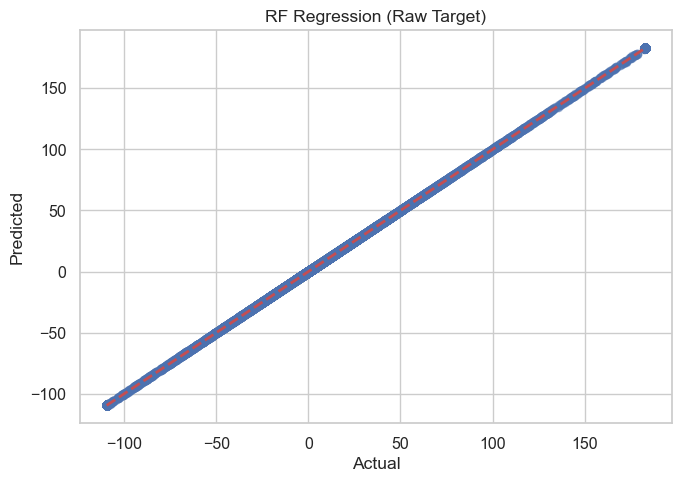

In [46]:
# ── 2.1 Train RF on raw regression target ───────────────────────────
print('='*60)
print('  Random Forest — Regression (Raw Target)')
print('='*60)

tkey = 'regression_raw'
data = prepare_target_splits(tkey)

if data:
    rf_raw = RandomForestRegressor(
        n_estimators=N_ESTIMATORS,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    rf_raw.fit(data['X_train'], data['y_train'], sample_weight=data['w_train'])

    y_pred = rf_raw.predict(data['X_test'])
    metrics = evaluate_regression(data['y_test'], y_pred)

    print('Metrics:', metrics)
    plot_regression_results(data['y_test'], y_pred, 'RF Regression (Raw Target)')

    trained_models[tkey] = rf_raw
    summary_rows.append({'Target': tkey, 'Model': 'Regressor', **to_serializable(metrics)})
else:
    print(f'⚠️  Target "{tkey}" not available')

---

## 3. Random Forest for Regression — Log-Transformed Target (`target_log`)

We train a Random Forest to predict the **log-transformed** target value.

  Random Forest — Regression (Log Target)
   Train: (77455, 19) | Val: (16597, 19) | Test: (16598, 19)
Metrics: {'MAE': 0.0001321722542233167, 'MSE': 2.2658094326500817e-07, 'RMSE': np.float64(0.00047600519247693944), 'R2': 0.9999999675214293}


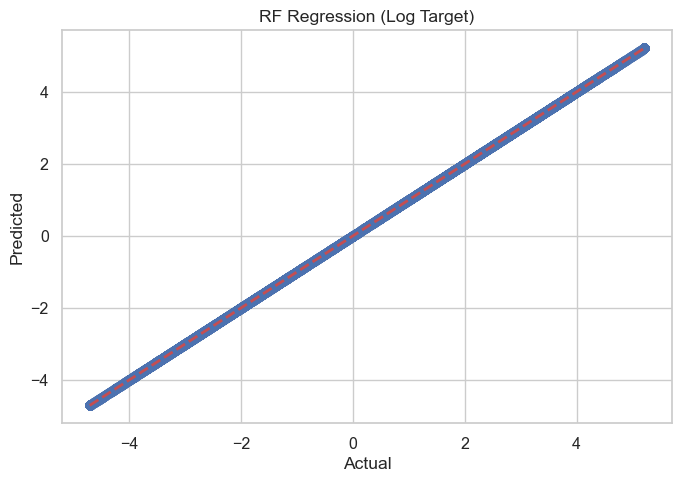

In [47]:
# ── 3.1 Train RF on log regression target ───────────────────────────
print('='*60)
print('  Random Forest — Regression (Log Target)')
print('='*60)

tkey = 'regression_log'
data = prepare_target_splits(tkey)

if data:
    rf_log = RandomForestRegressor(
        n_estimators=N_ESTIMATORS,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    rf_log.fit(data['X_train'], data['y_train'], sample_weight=data['w_train'])

    y_pred = rf_log.predict(data['X_test'])
    metrics = evaluate_regression(data['y_test'], y_pred)

    print('Metrics:', metrics)
    plot_regression_results(data['y_test'], y_pred, 'RF Regression (Log Target)')

    trained_models[tkey] = rf_log
    summary_rows.append({'Target': tkey, 'Model': 'Regressor', **to_serializable(metrics)})
else:
    print(f'⚠️  Target "{tkey}" not available')

---

## 4. Random Forest for Binary Classification (`target_binary`)

We train a Random Forest to decide **yes/no** for the binary target.

  Random Forest — Binary Classification
   Train: (77455, 19) | Val: (16597, 19) | Test: (16598, 19)
Metrics: {'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1': 1.0, 'ROC_AUC': 1.0}

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7512
           1       1.00      1.00      1.00      9086

    accuracy                           1.00     16598
   macro avg       1.00      1.00      1.00     16598
weighted avg       1.00      1.00      1.00     16598



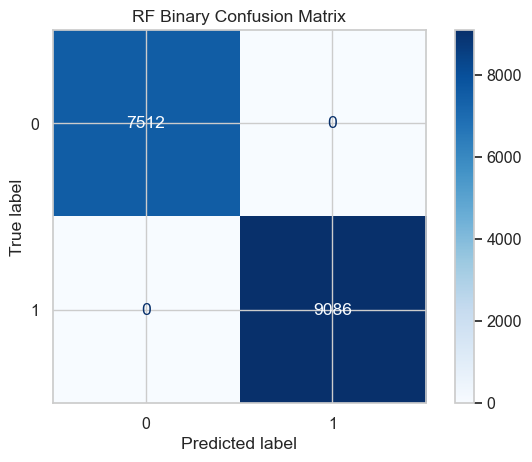

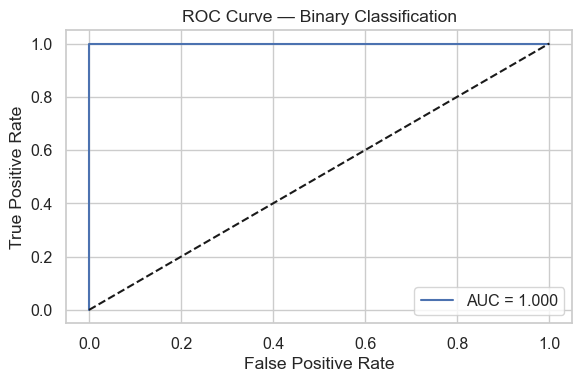

In [48]:
# ── 4.1 Train RF on binary classification target ─────────────────────
print('='*60)
print('  Random Forest — Binary Classification')
print('='*60)

tkey = 'binary_classification'
data = prepare_target_splits(tkey)

if data:
    rf_bin = RandomForestClassifier(
        n_estimators=N_ESTIMATORS,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    rf_bin.fit(data['X_train'], data['y_train'], sample_weight=data['w_train'])

    y_pred = rf_bin.predict(data['X_test'])
    y_proba = rf_bin.predict_proba(data['X_test'])[:, 1] if hasattr(rf_bin, 'predict_proba') else None

    metrics = evaluate_classification(data['y_test'], y_pred, y_proba, average='binary')
    print('Metrics:', metrics)
    print('\nClassification Report:')
    print(classification_report(data['y_test'], y_pred, zero_division=0))
    plot_confusion(data['y_test'], y_pred, 'RF Binary Confusion Matrix')

    if y_proba is not None:
        fpr, tpr, _ = roc_curve(data['y_test'], y_proba)
        plt.figure(figsize=(6, 4))
        plt.plot(fpr, tpr, label=f'AUC = {metrics.get("ROC_AUC", 0):.3f}')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve — Binary Classification')
        plt.legend()
        plt.tight_layout()
        plt.show()

    trained_models[tkey] = rf_bin
    summary_rows.append({'Target': tkey, 'Model': 'Classifier', **to_serializable(metrics)})
else:
    print(f'⚠️  Target "{tkey}" not available')

---

## 5. Random Forest for Multiclass Classification (`target_class3`)

We train a Random Forest to choose **1 of 3 classes** for the multiclass target.

  Random Forest — Multiclass Classification
   Train: (77455, 19) | Val: (16597, 19) | Test: (16598, 19)
Metrics: {'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1': 1.0}

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5462
           1       1.00      1.00      1.00      5462
           2       1.00      1.00      1.00      5674

    accuracy                           1.00     16598
   macro avg       1.00      1.00      1.00     16598
weighted avg       1.00      1.00      1.00     16598



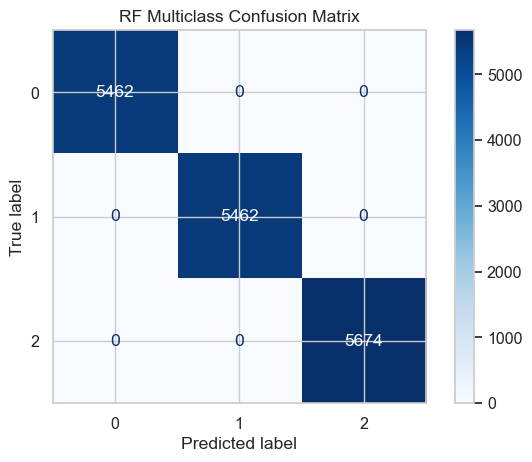

In [49]:
# ── 5.1 Train RF on multiclass target ────────────────────────────────
print('='*60)
print('  Random Forest — Multiclass Classification')
print('='*60)

tkey = 'multiclass_3'
data = prepare_target_splits(tkey)

if data:
    rf_multi = RandomForestClassifier(
        n_estimators=N_ESTIMATORS,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    rf_multi.fit(data['X_train'], data['y_train'], sample_weight=data['w_train'])

    y_pred = rf_multi.predict(data['X_test'])
    metrics = evaluate_classification(data['y_test'], y_pred, average='macro')

    print('Metrics:', metrics)
    print('\nClassification Report:')
    print(classification_report(data['y_test'], y_pred, zero_division=0))
    plot_confusion(data['y_test'], y_pred, 'RF Multiclass Confusion Matrix')

    trained_models[tkey] = rf_multi
    summary_rows.append({'Target': tkey, 'Model': 'Classifier', **to_serializable(metrics)})
else:
    print(f'⚠️  Target "{tkey}" not available')

---

## 6. Feature Importance Analysis

Feature importance shows which input clues are most helpful.

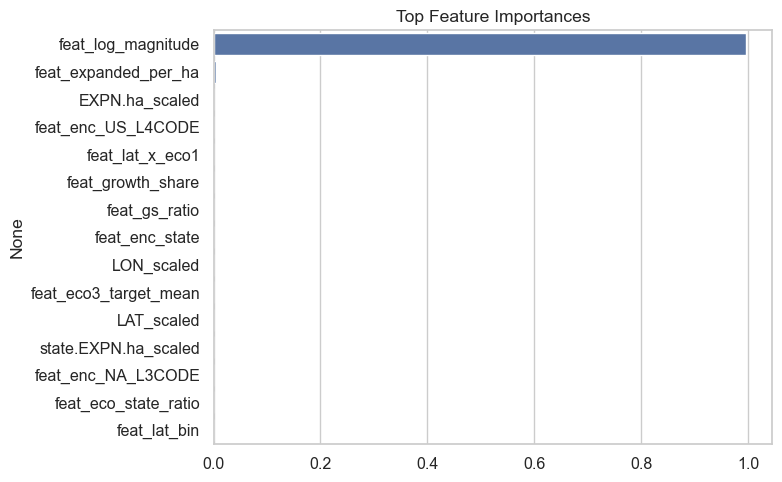

In [50]:
# ── 6.1 Feature importances (use log regression if available) ────────
model_for_importance = trained_models.get('regression_log') or trained_models.get('regression_raw')

if model_for_importance is not None:
    plot_feature_importance(model_for_importance, FEATURES, top_n=15)
else:
    print('⚠️  No regression model available for feature importance')

---

## 7. Summary — All Targets

This table compares all model results in one place.

,Target,Model,MAE,MSE,RMSE,R2,Accuracy,Precision,Recall,F1,ROC_AUC
0,regression_raw,Regressor,0.0036,0.0003,0.0175,1.0,NaN,NaN,NaN,NaN,NaN
1,regression_log,Regressor,0.0001,0.0000,0.0005,1.0,NaN,NaN,NaN,NaN,NaN
2,binary_classification,Classifier,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0
3,multiclass_3,Classifier,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,NaN


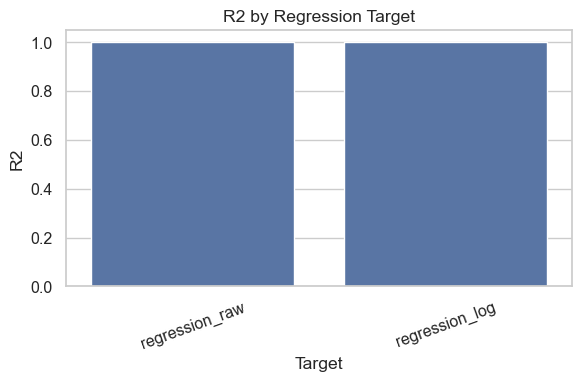

In [51]:
# ── 7.1 Summary table ────────────────────────────────────────────────
if summary_rows:
    summary_df = pd.DataFrame(summary_rows)
    display(summary_df.round(4))

    # Simple comparison chart for regression metrics
    reg_df = summary_df[summary_df['Model'] == 'Regressor']
    if not reg_df.empty:
        plt.figure(figsize=(6, 4))
        sns.barplot(data=reg_df, x='Target', y='R2')
        plt.title('R2 by Regression Target')
        plt.xticks(rotation=20)
        plt.tight_layout()
        plt.show()
else:
    print('⚠️  No results to summarize')

---

## 8. Save Models & Reports

We save the trained models and metrics so you can use them later.

In [52]:
# ── 8.1 Save trained models ──────────────────────────────────────────
for tkey, model in trained_models.items():
    model_path = os.path.join(MODELS_DIR, f'random_forest_{tkey}.joblib')
    joblib.dump(model, model_path)
    print(f'✅ Saved model: {model_path}')

# ── 8.2 Save metrics to JSON ─────────────────────────────────────────
if summary_rows:
    report_path = os.path.join(REPORTS_DIR, 'random_forest_metrics.json')
    with open(report_path, 'w') as f:
        json.dump(summary_rows, f, indent=2)
    print(f'✅ Saved metrics: {report_path}')

✅ Saved model: outputs\models\random_forest_regression_raw.joblib
✅ Saved model: outputs\models\random_forest_regression_log.joblib
✅ Saved model: outputs\models\random_forest_binary_classification.joblib
✅ Saved model: outputs\models\random_forest_multiclass_3.joblib
✅ Saved metrics: outputs\reports\random_forest_metrics.json


---

## 🏁 Summary

This notebook trained Random Forest models for **regression** and **classification**, generated evaluation plots, and saved metrics/models for reporting.